## Description

This file includes analysis and cleaning of the data that will help during the preprocessing and training steps.

The dataset has 7442 rows and 11 columns:

date - when the ad was posted  <br>
views - number of views ad has had  <br>
rooms - number of rooms of the apartment  <br>
size - size of the apartment in meters squared <br>
reconstructed - whether the apartment has been reconstructed (most apartments in Slovakia have been constructed between 1945 and 1989) <br>
garage - whether the apartment has a garage  <br>
balcony - whether the apartment has a balcony  <br>
price - price at which the apartment is being sold  <br>
new - whether the apartment house is newly built (generally not more than 10 years old)  <br>
location - town the apartment is in  <br>
top - whether the ad has been promoted on the ad site  <br>

Source: https://www.kaggle.com/datasets/petervboch/apartment-prices-in-slovakia

## Import libraries

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.close("all")
plt.style.use('ggplot')

## Basic exploration and cleaning

In [47]:
df = pd.read_csv('data/apartments_slovakia_2025-9-9.csv')

In [48]:
df.head(10)

,date,views,rooms,size,reconstructed,garage,balcony,price,new,location,top
0,2025-09-05,101,2.0,58.0,False,False,False,275000.0,True,Košice,False
1,2025-09-05,90,3.0,130.0,True,False,True,140000.0,True,Senica,False
2,2025-09-05,168,3.0,66.0,True,False,True,108500.0,True,Bánovce nad Bebravou,False
3,2025-09-05,102,3.0,84.0,True,False,True,183000.0,True,Nitra,False
4,2025-09-05,78,2.0,54.0,False,False,True,179000.0,True,Prešov,False
5,2025-09-05,326,2.0,90.0,False,True,False,273000.0,True,Košice,False
6,2025-09-05,133,0.0,4.0,True,False,True,88000.0,False,Prešov,False
7,2025-09-05,73,2.0,53.0,False,False,False,125000.0,True,Michalovce,False
8,2025-09-05,91,5.0,65.0,True,False,True,163000.0,False,Prešov,False
9,2025-09-05,119,2.0,48.0,True,False,True,147906.0,False,Piešťany,False


In [49]:
df = df.replace(False, 0)
df = df.replace(True, 1)

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7442 entries, 0 to 7441
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           7442 non-null   str    
 1   views          7442 non-null   int64  
 2   rooms          7442 non-null   float64
 3   size           7442 non-null   float64
 4   reconstructed  7442 non-null   object 
 5   garage         7442 non-null   object 
 6   balcony        7442 non-null   object 
 7   price          7442 non-null   float64
 8   new            7442 non-null   object 
 9   location       7442 non-null   str    
 10  top            7442 non-null   object 
dtypes: float64(3), int64(1), object(5), str(2)
memory usage: 639.7+ KB


In [51]:
df = df.astype({'reconstructed': 'int64', 
                'garage': 'int64', 
                'balcony': 'int64', 
                'new': 'int64',
                'top': 'int64',
                'date': 'datetime64[ns]'})

In [52]:
df.duplicated().sum()

np.int64(2)

In [53]:
df[ df.duplicated(keep=False) ]

,date,views,rooms,size,reconstructed,garage,balcony,price,new,location,top
13,2025-09-05,153,2.0,23.0,1,0,0,180000.0,0,Trnava,0
1900,2025-09-05,153,2.0,23.0,1,0,0,180000.0,0,Trnava,0
3888,2025-09-06,30,3.0,73.0,0,0,1,199900.0,1,Ružomberok,0
3891,2025-09-06,30,3.0,73.0,0,0,1,199900.0,1,Ružomberok,0


In [54]:
df.drop_duplicates(inplace=True)

In [55]:
df.describe()

,date,views,rooms,size,reconstructed,garage,balcony,price,new,top
count,7440,7440.000000,7440.000000,7440.000000,7440.000000,7440.000000,7440.000000,7440.000000,7440.000000,7440.000000
mean,2025-08-22 21:20:19.354838784,446.618145,2.589785,58.026862,0.634140,0.154973,0.657392,165159.682124,0.428360,0.196640
min,2025-07-25 00:00:00,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2300.000000,0.000000,0.000000
25%,2025-08-14 00:00:00,185.000000,2.000000,39.000000,0.000000,0.000000,0.000000,105687.500000,0.000000,0.000000
50%,2025-08-26 00:00:00,312.000000,3.000000,62.000000,1.000000,0.000000,1.000000,144900.000000,0.000000,0.000000
75%,2025-09-03 00:00:00,511.250000,3.000000,76.000000,1.000000,0.000000,1.000000,198000.000000,1.000000,0.000000
max,2025-09-07 00:00:00,9647.000000,11.000000,196.000000,1.000000,1.000000,1.000000,997000.000000,1.000000,1.000000
std,NaN,503.208861,1.016203,30.548165,0.481703,0.361903,0.474613,95659.337309,0.494874,0.397484


In [56]:
df[ (df['rooms'] == 0) | (df['size'] == 0) ]

,date,views,rooms,size,reconstructed,garage,balcony,price,new,location,top
6,2025-09-05,133,0.0,4.0,1,0,1,88000.0,0,Prešov,0
59,2025-08-14,391,0.0,20.0,1,0,0,113000.0,0,Bratislava,0
107,2025-07-28,645,0.0,21.0,0,0,1,45000.0,0,Levice,0
155,2025-09-07,35,0.0,20.0,0,0,0,82999.0,0,Brezno,0
176,2025-08-04,499,0.0,20.0,1,0,0,110000.0,0,Bratislava,0
...,...,...,...,...,...,...,...,...,...,...,...
7338,2025-08-28,1259,0.0,28.0,1,0,1,121900.0,1,Košice,1
7367,2025-08-28,311,0.0,130.0,1,0,0,23500.0,0,Michalovce,0
7396,2025-08-29,195,2.0,0.0,0,1,1,68000.0,0,Lučenec,0
7402,2025-07-31,974,0.0,18.0,0,0,0,125000.0,0,Bratislava,0


In [57]:
df = df[ (df['rooms'] > 0) & (df['size'] > 10) ]

In [58]:
df = df[ (df['price'] > 30_000) & (df['location'] != 'Česká republika') ]

In [59]:
df.info()

<class 'pandas.DataFrame'>
Index: 6403 entries, 0 to 7440
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           6403 non-null   datetime64[ns]
 1   views          6403 non-null   int64         
 2   rooms          6403 non-null   float64       
 3   size           6403 non-null   float64       
 4   reconstructed  6403 non-null   int64         
 5   garage         6403 non-null   int64         
 6   balcony        6403 non-null   int64         
 7   price          6403 non-null   float64       
 8   new            6403 non-null   int64         
 9   location       6403 non-null   str           
 10  top            6403 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(6), str(1)
memory usage: 600.3 KB


In [60]:
df.describe()

,date,views,rooms,size,reconstructed,garage,balcony,price,new,top
count,6403,6403.000000,6403.000000,6403.000000,6403.000000,6403.000000,6403.000000,6403.000000,6403.000000,6403.000000
mean,2025-08-22 21:47:05.238169600,447.614712,2.677026,65.299524,0.649383,0.154927,0.662346,168023.869124,0.430736,0.199438
min,2025-07-25 00:00:00,3.000000,1.000000,11.000000,0.000000,0.000000,0.000000,30500.000000,0.000000,0.000000
25%,2025-08-14 00:00:00,186.000000,2.000000,50.000000,0.000000,0.000000,0.000000,109000.000000,0.000000,0.000000
50%,2025-08-26 00:00:00,310.000000,3.000000,65.000000,1.000000,0.000000,1.000000,146355.000000,0.000000,0.000000
75%,2025-09-03 00:00:00,509.000000,3.000000,78.000000,1.000000,0.000000,1.000000,199000.000000,1.000000,0.000000
max,2025-09-07 00:00:00,9647.000000,11.000000,196.000000,1.000000,1.000000,1.000000,997000.000000,1.000000,1.000000
std,NaN,510.312697,0.941601,25.099530,0.477200,0.361864,0.472947,95751.570152,0.495218,0.399609


In [61]:
df = df[['rooms', 'size', 'reconstructed', 'garage', 'balcony', 'new', 'location', 'price']]

In [62]:
df.head()

,rooms,size,reconstructed,garage,balcony,new,location,price
0,2.0,58.0,0,0,0,1,Košice,275000.0
1,3.0,130.0,1,0,1,1,Senica,140000.0
2,3.0,66.0,1,0,1,1,Bánovce nad Bebravou,108500.0
3,3.0,84.0,1,0,1,1,Nitra,183000.0
4,2.0,54.0,0,0,1,1,Prešov,179000.0


In [63]:
df.info()

<class 'pandas.DataFrame'>
Index: 6403 entries, 0 to 7440
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   rooms          6403 non-null   float64
 1   size           6403 non-null   float64
 2   reconstructed  6403 non-null   int64  
 3   garage         6403 non-null   int64  
 4   balcony        6403 non-null   int64  
 5   new            6403 non-null   int64  
 6   location       6403 non-null   str    
 7   price          6403 non-null   float64
dtypes: float64(3), int64(4), str(1)
memory usage: 450.2 KB


## Correlations

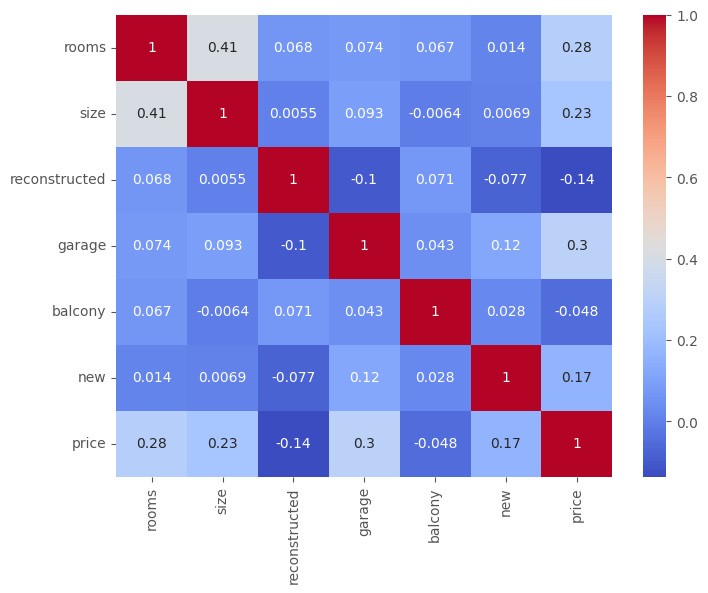

In [64]:
corr = df.corr(numeric_only=True)

plt.figure( figsize=(8, 6) )
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

## Attributes value distributions

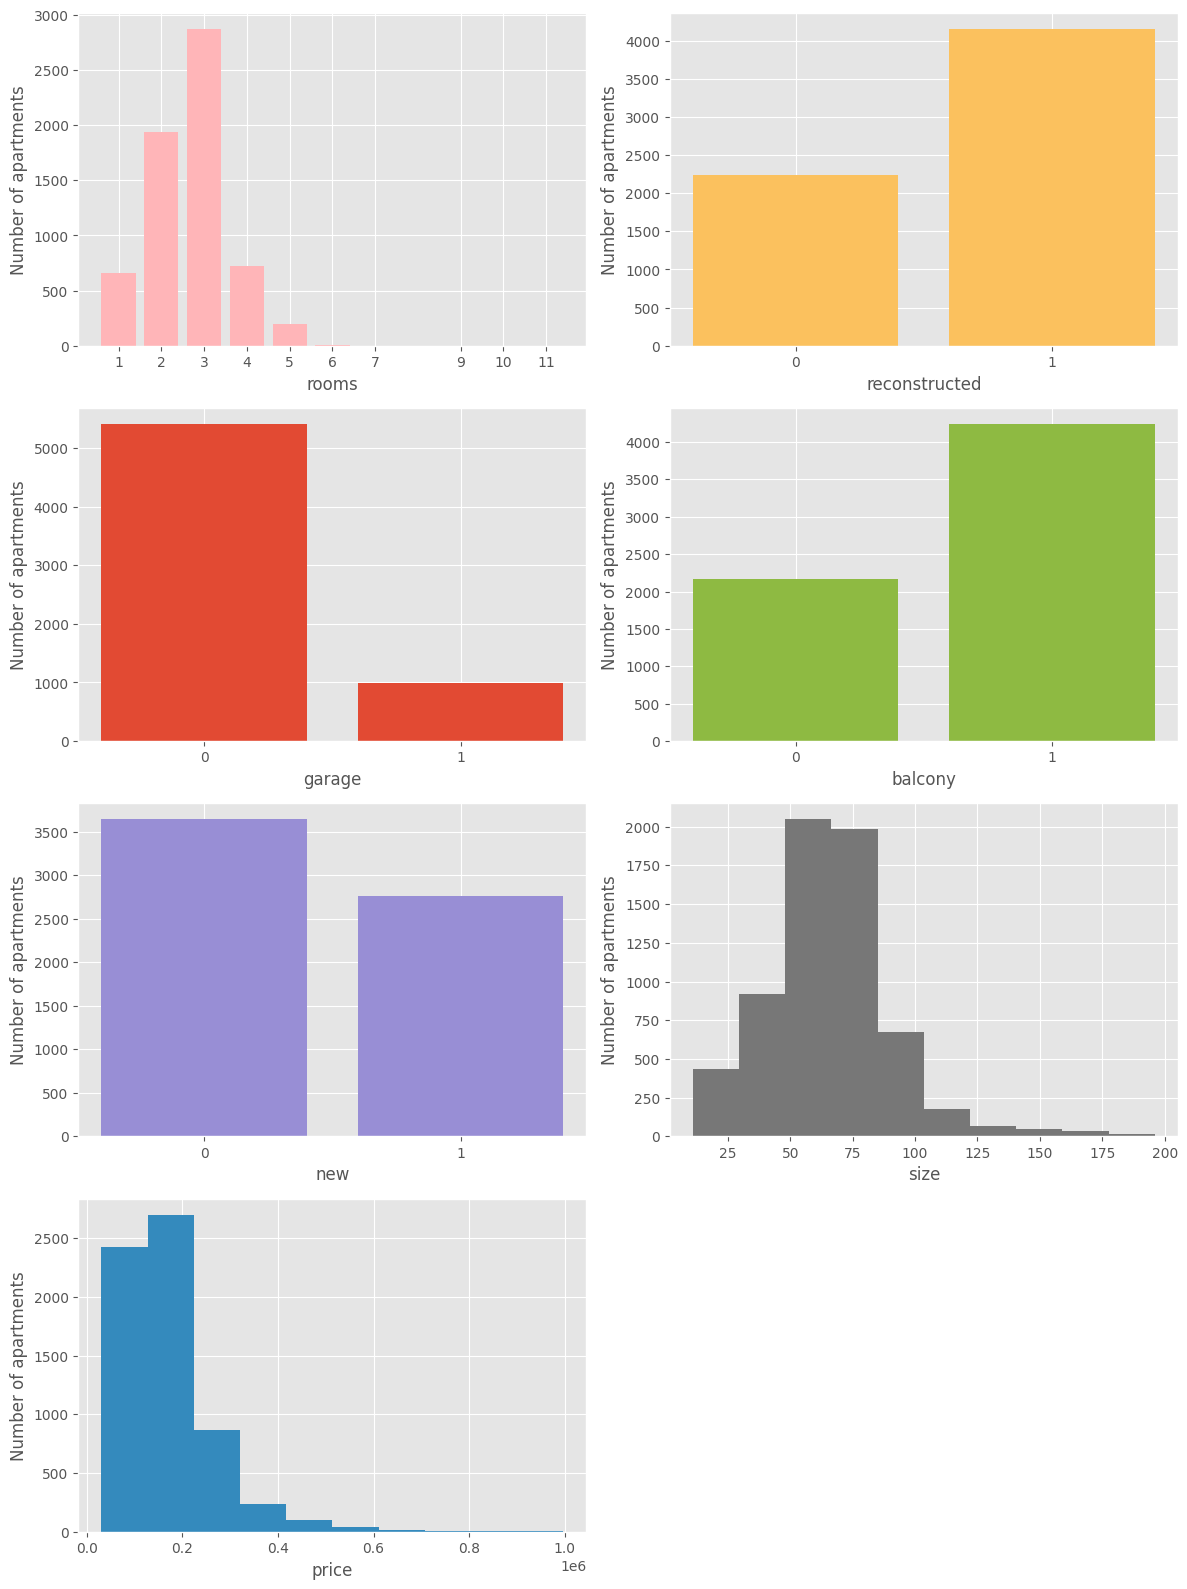

In [65]:
plt.figure( figsize=(12, 16) )


plt.subplot(4, 2, 1)
d = df['rooms'].value_counts()
plt.bar(d.index, d.values, color='#FFB5B8')
plt.xticks(d.index)
plt.xlabel('rooms')
plt.ylabel('Number of apartments')


plt.subplot(4, 2, 2)
d = df['reconstructed'].value_counts()
plt.bar(d.index, d.values, color='#FBC15E')
plt.xticks(d.index)
plt.xlabel('reconstructed')
plt.ylabel('Number of apartments')


plt.subplot(4, 2, 3)
d = df['garage'].value_counts()
plt.bar(d.index, d.values, color='#E24A33')
plt.xticks(d.index)
plt.xlabel('garage')
plt.ylabel('Number of apartments')


plt.subplot(4, 2, 4)
d = df['balcony'].value_counts()
plt.bar(d.index, d.values, color='#8EBA42')
plt.xticks(d.index)
plt.xlabel('balcony')
plt.ylabel('Number of apartments')


plt.subplot(4, 2, 5)
d = df['new'].value_counts()
plt.bar(d.index, d.values, color='#988ED5')
plt.xticks(d.index)
plt.xlabel('new')
plt.ylabel('Number of apartments')


plt.subplot(4, 2, 6)
plt.hist(df['size'], color='#777777')
plt.xlabel('size')
plt.ylabel('Number of apartments')


plt.subplot(4, 2, 7)
plt.hist(df['price'], color='#348ABD')
plt.xlabel('price')
plt.ylabel('Number of apartments')


plt.tight_layout()
plt.show()

## Boxplots

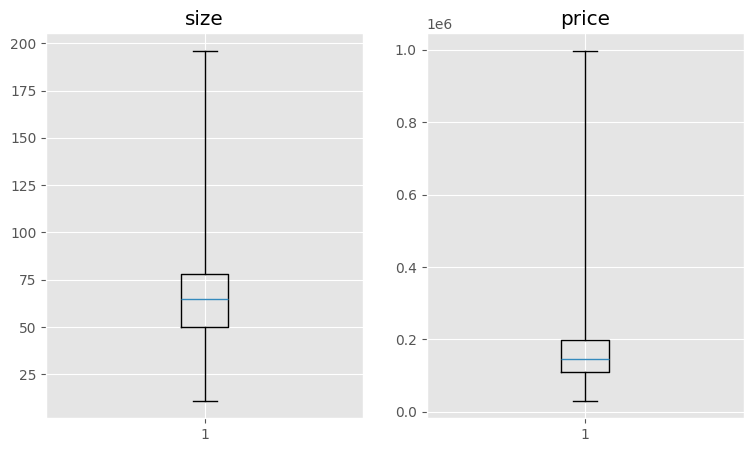

In [66]:
plt.figure( figsize=(9, 5) )


plt.subplot(1, 2, 1)
plt.boxplot(df['size'], whis=(0, 100))
plt.title('size')


plt.subplot(1, 2, 2)
plt.boxplot(df['price'], whis=(0, 100))
plt.title('price')


plt.show()

## Attribute location

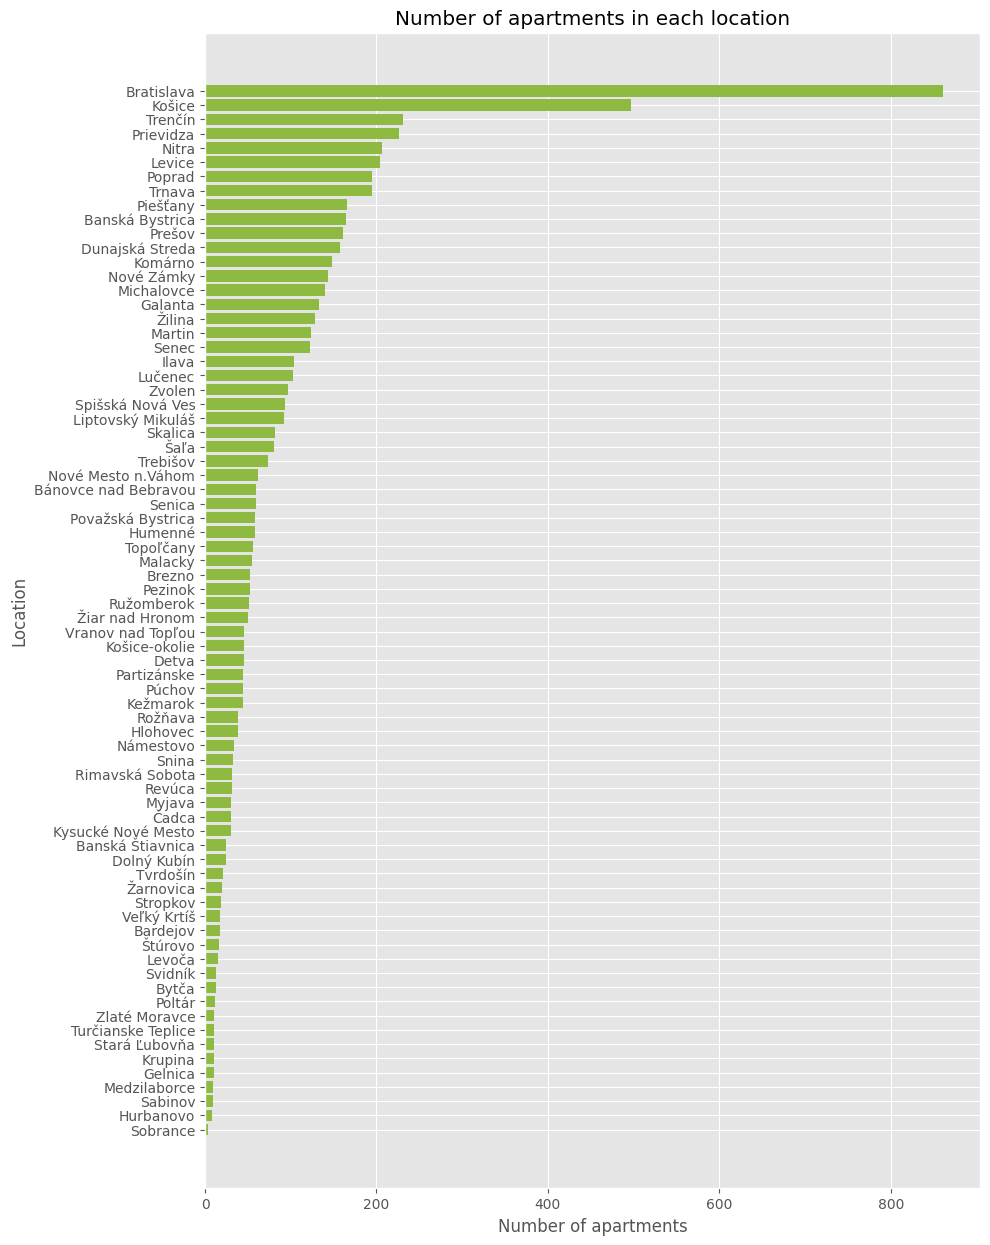

In [67]:
d = df['location'].value_counts().sort_values()

plt.figure( figsize=(10, 15) )
plt.barh(d.index, d.values, color='#8EBA42')
plt.xlabel('Number of apartments')
plt.ylabel('Location')
plt.title('Number of apartments in each location')
plt.show()

## Saving cleaned data

In [68]:
df.to_csv('data/cleaned.csv', index=False)